# Corpus Data Preparation

Cleans and normalises the raw corpus, builds sentence embeddings, **automatically** finds
the best number of topic clusters, generates descriptive cluster names from the top words,
and writes `corpus_nodes_clustered.toml`.

**Workflow:**
1. Load all JSON files
2. Filter bad scrapes (`MIN_BODY_LEN`)
3. Clean / normalise text (encoding artefacts, boilerplate)
4. Embed with `sentence-transformers` — **full body, no truncation**
5. UMAP 2-D visualisation coloured by original prefix
6. Auto-select best k via silhouette score over `K_RANGE`
7. Apply KMeans; show UMAP coloured by cluster
8. **Auto-generate cluster names** from top TF-IDF terms
9. Inspect clusters; optionally override names in `CLUSTER_TO_NODE`
10. Export `corpus_nodes_clustered.toml`


## 0 — Configuration

All tunable parameters live here. Re-run the notebook after changing any value.


In [5]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
CORPUS_DIR      = Path("corpus")
EMBED_CACHE     = Path(".embeddings_cache.npy")  # delete to force re-encoding
OUTPUT_TOML     = Path("corpus_nodes_clustered.toml")
OUTPUT_MANIFEST = Path("cluster_assignments.json")

# ── Quality filter ─────────────────────────────────────────────────────────
MIN_BODY_LEN = 150  # characters after cleaning; shorter = likely bad scrape
# Upper bound for histogram only; set to None for no cap.
BODY_LEN_MAX = None

# Histogram: use log scale to spread long tails.
HIST_XSCALE = "log"  # "linear" or "log"
HIST_BINS = 60

# ── Link bias (optional) ───────────────────────────────────────────────────
LINK_BIAS_WEIGHT = 0.3  # 0 disables link bias
LINK_SVD_DIMS = 32
LINK_SOURCE = "body"  # "body" or "body_clean"
LINK_EDGE_SAMPLE = None  # None draws all edges

# ── Embedding ──────────────────────────────────────────────────────────────
# Full body is encoded — no length cap.
# Swap model for quality vs. speed trade-off:
#   fast : all-MiniLM-L6-v2
#   best : all-mpnet-base-v2
EMBED_MODEL = "all-mpnet-base-v2"

# ── UMAP ───────────────────────────────────────────────────────────────────
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST  = 0.1
RANDOM_STATE   = 42

# ── Dynamic clustering ─────────────────────────────────────────────────────
# The notebook scans every k in K_RANGE and picks the one with the highest
# silhouette score automatically.
# Set FORCE_K to an int to skip the search and use that k directly.
K_RANGE = (4, 25)   # (min_k, max_k) inclusive
FORCE_K = None      # e.g. FORCE_K = 8 to lock a specific k

# ── Cluster naming ──────────────────────────────────────────────────────────
# Auto-generated names from top TF-IDF terms. Leave empty dict to use auto-names.
# Override specific clusters by filling in cluster_id -> custom_name.
CLUSTER_TO_NODE: dict[int, str] = {
    # 0: "my_custom_name",   # override auto-generated name
    # 1: "another_name",
}

print("Config OK")


Config OK


## 1 — Load corpus


In [6]:
import json
import pandas as pd

records = []
for path in sorted(CORPUS_DIR.glob("*.json")):
    try:
        doc = json.loads(path.read_text(encoding="utf-8"))
    except Exception as e:
        records.append({"file": path.name, "url": "", "title": "",
                        "body": "", "topic_prefix": "PARSE_ERROR",
                        "parse_error": str(e)})
        continue
    name         = path.name
    topic_prefix = name.split("__")[0] if "__" in name else "(no prefix)"
    records.append({
        "file":         name,
        "url":          doc.get("url", ""),
        "title":        doc.get("title", ""),
        "body":         doc.get("body", ""),
        "topic_prefix": topic_prefix,
        "parse_error":  "",
    })

df = pd.DataFrame(records)
print(f"Total files: {len(df)}")
print()
print("Files per topic prefix:")
print(df["topic_prefix"].value_counts().to_string())


Total files: 1574

Files per topic prefix:
topic_prefix
smart_manufacturing      278
space                    199
economics                187
football                 187
climate_change           169
ml_algorithms            127
medicine                 118
neuroscience             108
programming               79
sustainable_materials     62
quantum_computing         60


## 2 — Clean & normalise text

Fixes encoding artefacts (mojibake), strips residual HTML, and removes JS boilerplate
left by the scraper. Inspect the before/after examples to verify correctness.


In [7]:
import re
import html

# Mojibake: UTF-8 characters that were decoded as Latin-1 during scraping.
# We map the garbled byte sequences back to the correct Unicode characters.
_MOJIBAKE = {
    "\u00c2\u00b6": "\u00b6",          # paragraph sign
    "\u00e2\u20ac\u2122": "'",         # right single quotation
    "\u00e2\u20ac\u0153": '"',         # left double quotation
    "\u00e2\u20ac\u009d": '"',         # right double quotation
    "\u00e2\u20ac\u201c": "\u2013",    # en dash
    "\u00e2\u20ac\u201d": "\u2014",    # em dash
    "\u00e2\u20ac\u00a6": "\u2026",    # ellipsis
    "\u00c2\u00a9": "\u00a9",          # copyright
    "\u00c2\u00ae": "\u00ae",          # registered trademark
    "\u00c2\u00b7": "\u00b7",          # middle dot
    "\u00c2\u00a0": " ",               # non-breaking space
}

# Boilerplate phrases that indicate a failed or partial scrape.
_BOILERPLATE = re.compile(
    r"Loading component\.{0,3}"
    r"|Past Events\s+View Upcoming"
    r"|This content is now at"
    r"|Please enable JavaScript"
    r"|To view this (video|page) please enable"
    r"|Cookie\s+(Policy|Settings|Notice)"
    , re.IGNORECASE,
)

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = html.unescape(text)                       # &amp; &lt; etc.
    for bad, good in _MOJIBAKE.items():              # fix mojibake
        text = text.replace(bad, good)
    text = re.sub(r"<[^>]{1,200}>", " ", text)      # strip HTML tags
    text = _BOILERPLATE.sub(" ", text)              # remove boilerplate
    text = re.sub(r"[ \t]{2,}", " ", text)          # collapse spaces
    text = re.sub(r"\n{3,}", "\n\n", text)          # collapse blank lines
    return text.strip()


df["title_clean"] = df["title"].apply(clean_text)
df["body_clean"]  = df["body"].apply(clean_text)
df["body_len"]    = df["body_clean"].str.len()

# Spot-check: show a few files where cleaning changed something.
SPOT_CHECK_N = 3
changed = df[df["body_clean"] != df["body"]].head(SPOT_CHECK_N)
for _, row in changed.iterrows():
    print(f"FILE: {row['file']}")
    print(f"  BEFORE: {row['body'][:200]!r}")
    print(f"  AFTER : {row['body_clean'][:200]!r}")
    print()
print(f"Total docs with cleaning changes: {len(df[df['body_clean'] != df['body']])}")


FILE: climate_change__arctic_sea_ice_minimum_extent_earth_indicator_nasa_science.json
  BEFORE: "Explore This Section Arctic Sea Ice Minimum Extent - Earth Indicator Key Takeaway: As Earth's atmosphere and ocean warm, seasonal melting of sea ice increases. This is most notable in the summer, when"
  AFTER : "Explore This Section Arctic Sea Ice Minimum Extent - Earth Indicator Key Takeaway: As Earth's atmosphere and ocean warm, seasonal melting of sea ice increases. This is most notable in the summer, when"

FILE: climate_change__carbon_budget.json
  BEFORE: 'A carbon budget is a concept used in politics of climate change to help set greenhouse gas emissions reduction targets in a fair and effective way. It examines the "maximum amount of cumulative net gl'
  AFTER : 'A carbon budget is a concept used in politics of climate change to help set greenhouse gas emissions reduction targets in a fair and effective way. It examines the "maximum amount of cumulative net gl'

FILE: climate_chang

## 3 — Filter bad documents


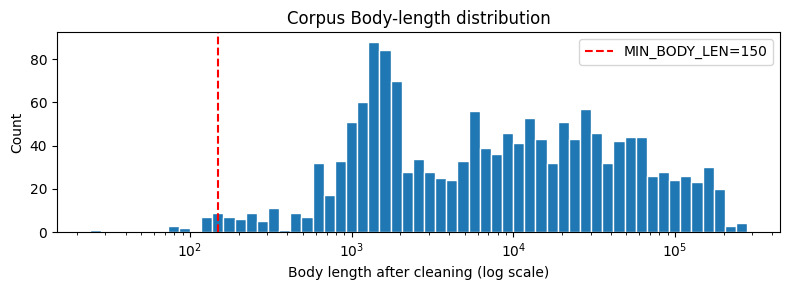


Documents below MIN_BODY_LEN (150 chars): 19


,file,body_len,body_clean
150,climate_change__the_lancet_countdown_on_health...,147,Countdown Climate change Public health Politic...
252,economics__how_markets_slowly_digest_changes_i...,75,Supply and demand Economics Business Industria...
254,economics__ias_versus_us_gaap_information_asym...,79,Information asymmetry Business Accounting Fina...
292,economics__monetary_policy_rules_in_practice.json,79,Economics Monetary policy Keynesian economics ...
335,economics__the_psychology_of_sunk_cost.json,129,Sunk costs Investment (military) Economics Mic...
345,economics__world_bank_group_experts.json,24,World Bank Group Experts
348,economics__world_economic_outlook_all_issues.json,96,World Economic Outlook Page : 1 of 0 Publicati...
460,football__metalac_beograd_wikipedia.json,118,"Redirect to: OFK Beograd Retrieved from "" http..."
634,medicine__pueblos_ind_genas.json,144,Puede estar intentando tener acceso a este sit...
663,ml_algorithms__a_survey_on_model_based_reinfor...,129,Reinforcement learning Generalization Computer...


In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
body_len = df["body_len"]
if BODY_LEN_MAX is not None:
    body_len = body_len.clip(upper=BODY_LEN_MAX)

if HIST_XSCALE == "log":
    plot_len = body_len[body_len > 0]
    if len(plot_len) == 0:
        raise ValueError("HIST_XSCALE='log' requires positive body_len values")
    bins = np.logspace(np.log10(plot_len.min()), np.log10(plot_len.max()), HIST_BINS)
    ax.hist(plot_len, bins=bins, edgecolor="white")
    ax.set_xscale("log")
else:
    ax.hist(body_len, bins=HIST_BINS, edgecolor="white")

ax.axvline(MIN_BODY_LEN, color="red", linestyle="--",
           label=f"MIN_BODY_LEN={MIN_BODY_LEN}")
if BODY_LEN_MAX is not None:
    ax.axvline(BODY_LEN_MAX, color="gray", linestyle=":",
               label=f"BODY_LEN_MAX={BODY_LEN_MAX}")
xlabel = "Body length after cleaning"
if HIST_XSCALE == "log":
    xlabel += " (log scale)"
ax.set_xlabel(xlabel)
ax.set_ylabel("Count")
ax.set_title("Corpus Body-length distribution")
ax.legend()
plt.tight_layout(); plt.show()

bad = df[df["body_len"] < MIN_BODY_LEN]
print(f"\nDocuments below MIN_BODY_LEN ({MIN_BODY_LEN} chars): {len(bad)}")
bad[["file", "body_len", "body_clean"]]


In [9]:
# Add filenames here to force-keep a document despite being below MIN_BODY_LEN.
FORCE_KEEP: set[str] = set()

clean = df[
    (df["body_len"] >= MIN_BODY_LEN) | df["file"].isin(FORCE_KEEP)
].copy()
clean = clean[clean["parse_error"] == ""].reset_index(drop=True)
excluded = df[~df["file"].isin(clean["file"])]

print(f"Excluded (bad scrapes) : {len(excluded)}")
print(f"Clean documents        : {len(clean)}")


Excluded (bad scrapes) : 19
Clean documents        : 1555


In [10]:
import re
from urllib.parse import urlparse, urlunparse

def _normalize_url(u: str) -> str:
    if not u:
        return ""
    u = u.strip().rstrip(").,;:!?\"'")
    if u.startswith("www."):
        u = "http://" + u
    try:
        parsed = urlparse(u)
    except Exception:
        return ""
    if not parsed.netloc:
        return ""
    scheme = "https" if parsed.scheme in ("http", "https") else "https"
    netloc = parsed.netloc.lower()
    path = parsed.path.rstrip("/")
    return urlunparse((scheme, netloc, path, "", "", ""))

source_col = "body" if LINK_SOURCE == "body" else "body_clean"

url_to_indices: dict[str, list[int]] = {}
for idx, url in clean["url"].fillna("").items():
    norm = _normalize_url(url)
    if norm:
        url_to_indices.setdefault(norm, []).append(idx)

mapped_docs = sum(len(v) for v in url_to_indices.values())
print(f"URL mapped docs: {mapped_docs} / {len(clean)}")
print(f"Unique URLs: {len(url_to_indices)}")

link_pattern = re.compile(r"https?://[^\s)>\"]+")
link_edges = []
for idx, text in clean[source_col].fillna("").items():
    targets = set()
    for raw in link_pattern.findall(text):
        norm = _normalize_url(raw)
        if norm and norm in url_to_indices:
            for j in url_to_indices[norm]:
                if j != idx:
                    targets.add(j)
    for j in targets:
        link_edges.append((idx, j))

print(f"Matched link edges: {len(link_edges)}")

import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

link_features = None
if LINK_BIAS_WEIGHT > 0 and link_edges:
    rows, cols = zip(*link_edges)
    data = np.ones(len(link_edges), dtype=np.float32)
    adj = sp.coo_matrix((data, (rows, cols)), shape=(len(clean), len(clean)))
    adj = (adj + adj.T).tocsr()
    n_components = min(LINK_SVD_DIMS, max(1, len(clean) - 1))
    svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    link_features = svd.fit_transform(adj)
    link_features = normalize(link_features)
    print(f"Link features: {link_features.shape}")
else:
    print("Link bias disabled or no link matches found.")


URL mapped docs: 1555 / 1555
Unique URLs: 1511
Matched link edges: 20216
Link features: (1555, 32)


## 4 — Embed documents (full text, no truncation)

Each document is encoded as `title + " " + full_body`.  
Embeddings are cached — delete `.embeddings_cache.npy` to force a fresh run.


In [11]:
import numpy as np

texts = (clean["title_clean"] + " " + clean["body_clean"]).tolist()

reload = True
if EMBED_CACHE.exists():
    embeddings = np.load(EMBED_CACHE)
    if embeddings.shape[0] == len(texts):
        print(f"Loaded cached embeddings: {embeddings.shape}")
        reload = False
    else:
        print(f"Cache has {embeddings.shape[0]} rows but corpus has {len(texts)} — re-encoding.")

if reload:
    from sentence_transformers import SentenceTransformer
    print(f"Encoding {len(texts)} documents with '{EMBED_MODEL}' (full text) ...")
    model = SentenceTransformer(EMBED_MODEL)
    embeddings = model.encode(texts, show_progress_bar=True, batch_size=16)
    np.save(EMBED_CACHE, embeddings)
    print(f"Saved -> {EMBED_CACHE}  shape={embeddings.shape}")

link_features = globals().get("link_features", None)
if link_features is not None and link_features.shape[0] != embeddings.shape[0]:
    print("link_features size mismatch; ignoring link bias")
    link_features = None

if LINK_BIAS_WEIGHT > 0 and link_features is not None:
    from sklearn.preprocessing import normalize
    text_embeddings = normalize(embeddings)
    X = np.hstack([text_embeddings, LINK_BIAS_WEIGHT * link_features])
    print(f"Using combined embeddings (link weight={LINK_BIAS_WEIGHT})")
else:
    X = embeddings
    print("Using text embeddings only")


Loaded cached embeddings: (1555, 768)
Using combined embeddings (link weight=0.3)


## 5 — UMAP: visualise by original topic prefix

Shows how well (or poorly) the original filename prefixes separate in embedding space.  
Overlapping colours = documents that likely don't belong to that prefix.


/home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_208498/3456024148.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap("tab20", len(prefixes))


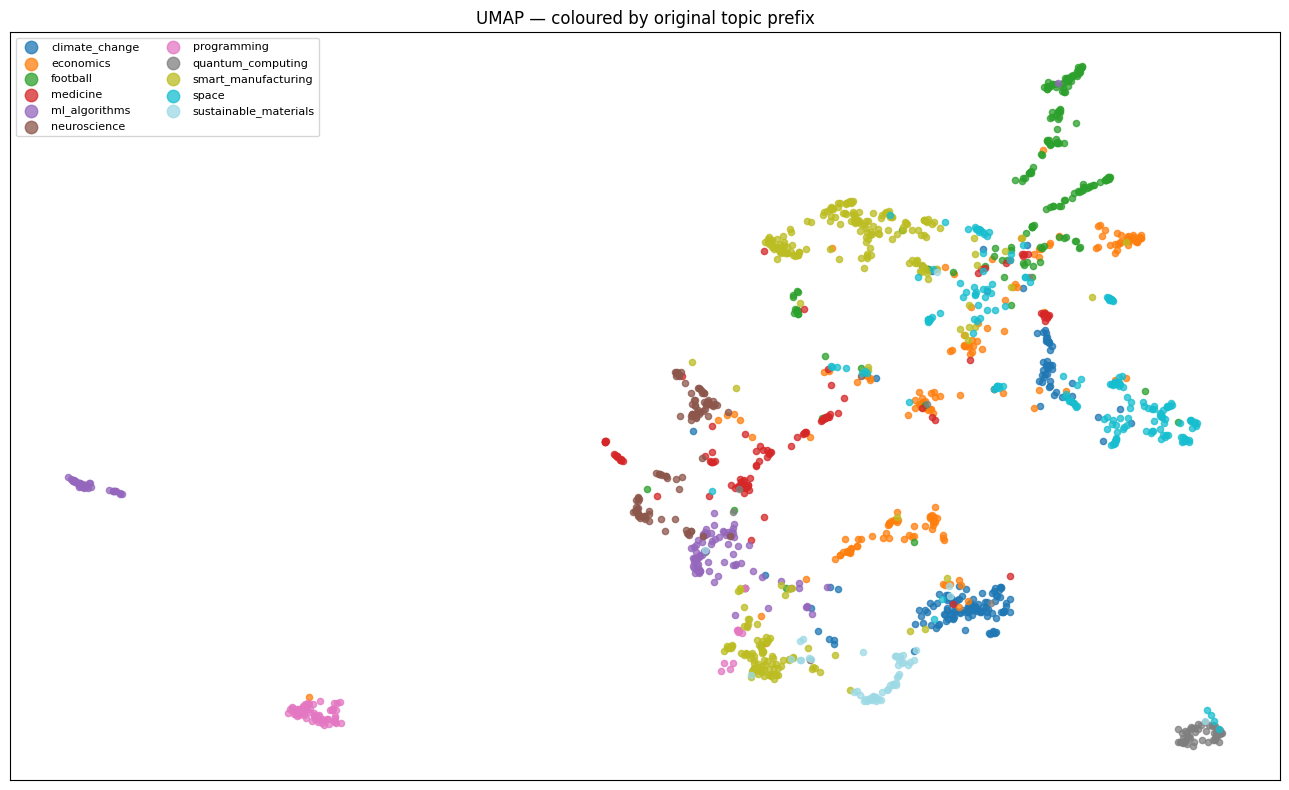

In [12]:
import umap as umap_lib

reducer = umap_lib.UMAP(
    n_neighbors  = UMAP_NEIGHBORS,
    min_dist     = UMAP_MIN_DIST,
    random_state = RANDOM_STATE,
    verbose      = False,
)
xy = reducer.fit_transform(X)
clean["umap_x"] = xy[:, 0]
clean["umap_y"] = xy[:, 1]

prefixes  = sorted(clean["topic_prefix"].unique())
cmap      = plt.cm.get_cmap("tab20", len(prefixes))
color_map = {p: cmap(i) for i, p in enumerate(prefixes)}

fig, ax = plt.subplots(figsize=(13, 8))
for prefix, grp in clean.groupby("topic_prefix"):
    ax.scatter(grp["umap_x"], grp["umap_y"],
               c=[color_map[prefix]], label=prefix, s=20, alpha=0.75)
ax.legend(markerscale=2, fontsize=8, loc="best", ncol=2)
ax.set_title("UMAP — coloured by original topic prefix")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


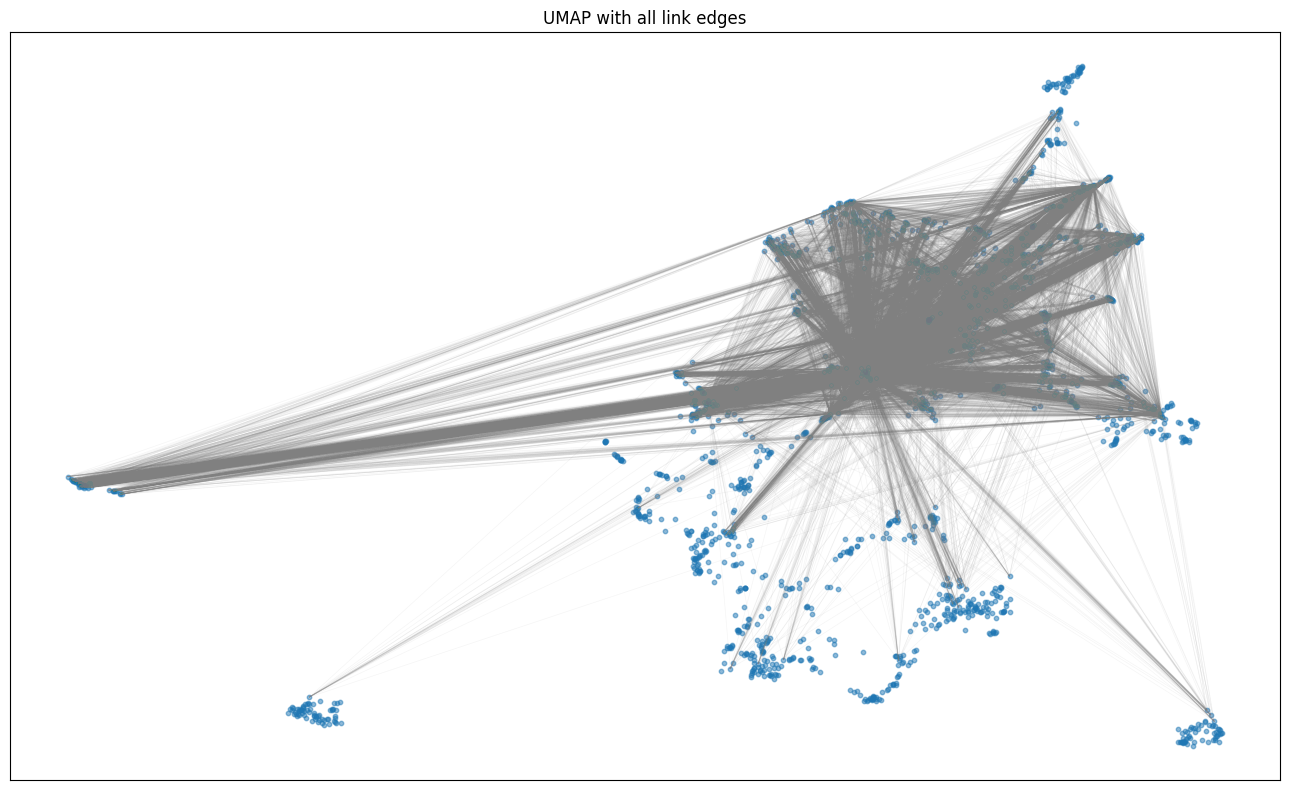

In [13]:
import numpy as np
import matplotlib.pyplot as plt

if "link_edges" in globals() and link_edges:
    if LINK_EDGE_SAMPLE is None:
        edge_idx = range(len(link_edges))
        title = "UMAP with all link edges"
    else:
        sample_n = min(LINK_EDGE_SAMPLE, len(link_edges))
        rng = np.random.default_rng(RANDOM_STATE)
        edge_idx = rng.choice(len(link_edges), size=sample_n, replace=False)
        title = f"UMAP with sampled link edges (n={sample_n})"
    fig, ax = plt.subplots(figsize=(13, 8))
    ax.scatter(clean["umap_x"], clean["umap_y"], s=10, alpha=0.5, color="tab:blue")
    for i in edge_idx:
        a, b = link_edges[i]
        ax.plot([clean.at[a, "umap_x"], clean.at[b, "umap_x"]],
                [clean.at[a, "umap_y"], clean.at[b, "umap_y"]],
                color="gray", alpha=0.08, linewidth=0.5)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print("No link edges available. Run the link graph cell first.")


Scanning k=4..25...................... done


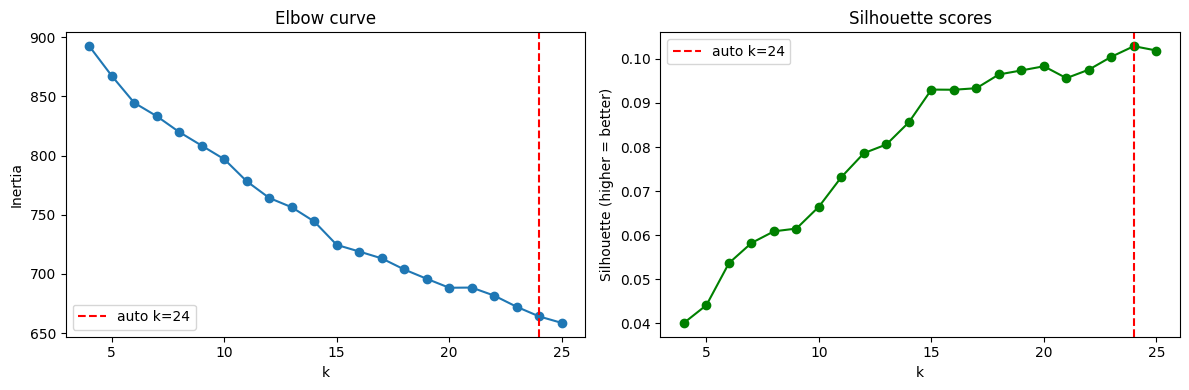


Auto-selected k=24  (silhouette=0.103)
To lock this: set FORCE_K=24 in the config cell.


In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

if FORCE_K is not None:
    best_k = FORCE_K
    print(f"FORCE_K={FORCE_K} — skipping auto-selection.")
else:
    k_min, k_max = K_RANGE
    k_range      = range(k_min, min(k_max + 1, len(clean) // 5))
    inertias, silhouettes = [], []

    print(f"Scanning k={k_min}..{k_max}", end="", flush=True)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil    = silhouette_score(X, labels,
                                  sample_size=min(600, len(clean)),
                                  random_state=RANDOM_STATE)
        silhouettes.append(sil)
        print(".", end="", flush=True)
    print(" done")

    best_idx = silhouettes.index(max(silhouettes))
    best_k   = list(k_range)[best_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(list(k_range), inertias, marker="o")
    ax1.axvline(best_k, color="red", linestyle="--", label=f"auto k={best_k}")
    ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
    ax1.set_title("Elbow curve"); ax1.legend()

    ax2.plot(list(k_range), silhouettes, marker="o", color="green")
    ax2.axvline(best_k, color="red", linestyle="--", label=f"auto k={best_k}")
    ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette (higher = better)")
    ax2.set_title("Silhouette scores"); ax2.legend()
    plt.tight_layout(); plt.show()

    print(f"\nAuto-selected k={best_k}  (silhouette={max(silhouettes):.3f})")
    print(f"To lock this: set FORCE_K={best_k} in the config cell.")


## 7 — Apply KMeans with auto-selected k


In [67]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
clean["cluster"] = km.fit_predict(X)

print(f"Cluster sizes (k={best_k}):")
print(clean["cluster"].value_counts().sort_index().to_string())


Cluster sizes (k=24):
cluster
0     18
1     42
2     55
3     41
4     57
5     52
6     40
7     63
8     24
9     27
10    36
11    71
12    60
13    68
14    36
15    42
16    32
17    21
18    26
19    37
20    44
21    32
22    49
23    41


## 8 — Auto-generate cluster names from top words

Uses TF-IDF to extract the top 3 most relevant terms per cluster.  
Combines them into a readable cluster name like `quantum_computing_error_correction`.  
Override in `CLUSTER_TO_NODE` if the auto-name doesn't feel right.


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# ── Extract top terms per cluster ──────────────────────────────────────────
def get_cluster_name(cluster_docs: list[str], n_words: int = 3) -> str:
    """Generate a cluster name from the top TF-IDF terms."""
    if not cluster_docs or len(cluster_docs) < 2:
        return "tiny_cluster"

    # Simple TF-IDF on the cluster alone
    vectorizer = TfidfVectorizer(
        max_features=200,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=1,
        max_df=0.9,
    )
    try:
        tfidf_matrix = vectorizer.fit_transform(cluster_docs)
        # Sum TF-IDF scores per term
        scores = tfidf_matrix.sum(axis=0).A1
        top_indices = scores.argsort()[-n_words:][::-1]
        terms = [vectorizer.get_feature_names_out()[i] for i in top_indices]
        # Clean up: remove spaces from bigrams, join with underscore
        terms = [re.sub(r'\s+', '_', t) for t in terms if t.strip()]
        return "_".join(terms[:n_words])
    except Exception as e:
        print(f"Warning: naming failed — {e}")
        return "cluster_unknown"


# ── Generate names for all clusters ────────────────────────────────────────
auto_names = {}
for cid in sorted(clean["cluster"].unique()):
    cluster_docs = clean[clean["cluster"] == cid]["body_clean"].tolist()
    auto_names[cid] = get_cluster_name(cluster_docs)

# ── Apply overrides from CLUSTER_TO_NODE ──────────────────────────────────
final_names = {cid: CLUSTER_TO_NODE.get(cid, name) for cid, name in auto_names.items()}

print("Auto-generated cluster names:")
for cid, name in sorted(final_names.items()):
    src = "(auto)" if auto_names[cid] == name else "(custom)"
    print(f"  Cluster {cid:2d} -> {name:30s}  {src}")


Auto-generated cluster names:
  Cluster  0 -> resistance_eskape_cancer        (auto)
  Cluster  1 -> university_russian_physics      (auto)
  Cluster  2 -> algorithm_variational_computer  (auto)
  Cluster  3 -> partizan_edit_retrieved         (auto)
  Cluster  4 -> data_models_neural              (auto)
  Cluster  5 -> football_model_data             (auto)
  Cluster  6 -> search_game_deep                (auto)
  Cluster  7 -> drug_heart_chemical             (auto)
  Cluster  8 -> flow_data_temperature           (auto)
  Cluster  9 -> roman_empire_language           (auto)
  Cluster 10 -> retrieved_open_science          (auto)
  Cluster 11 -> black_space_data                (auto)
  Cluster 12 -> climate_carbon_economics        (auto)
  Cluster 13 -> edit_2023_aruba                 (auto)
  Cluster 14 -> lignin_materials_mycelium       (auto)
  Cluster 15 -> retrieved_edit_africa           (auto)
  Cluster 16 -> god_religion_pagan              (auto)
  Cluster 17 -> 2020_covid_19      

## 9 — UMAP coloured by cluster with auto-generated names


/tmp/ipykernel_1703071/1316310920.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c = plt.cm.get_cmap("tab20", best_k)


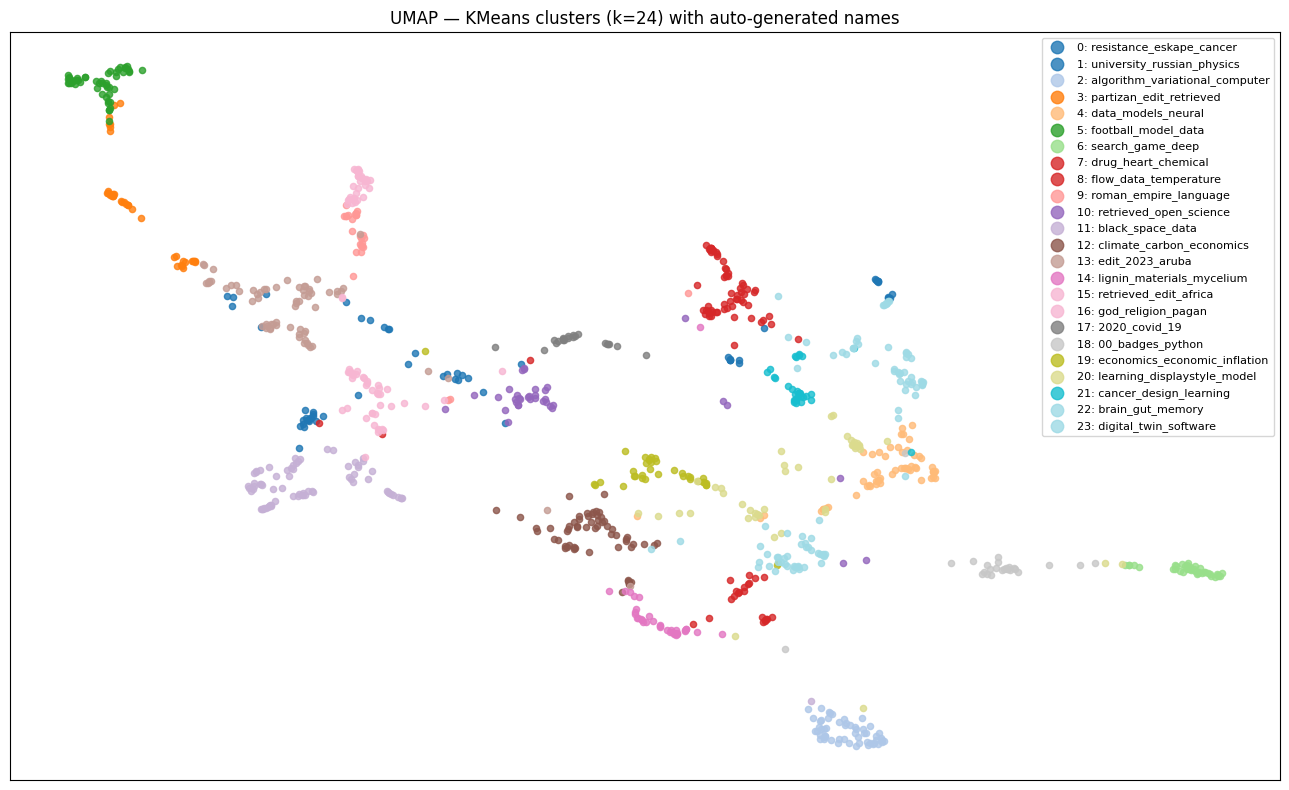

In [69]:
cmap_c = plt.cm.get_cmap("tab20", best_k)
fig, ax = plt.subplots(figsize=(13, 8))
for cid, grp in clean.groupby("cluster"):
    ax.scatter(grp["umap_x"], grp["umap_y"],
               c=[cmap_c(cid)], label=f"{cid}: {final_names[cid]}", s=20, alpha=0.8)
ax.legend(markerscale=2, fontsize=8, loc="best")
ax.set_title(f"UMAP — KMeans clusters (k={best_k}) with auto-generated names")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 10 — Inspect clusters

Read the auto-generated names and sample docs. If you want to rename any cluster,  
go back to the **config cell** and add it to `CLUSTER_TO_NODE`, then re-run Cell 7 onward.


In [23]:
TOP_N = 8  # sample docs printed per cluster

for cid in sorted(clean["cluster"].unique()):
    grp        = clean[clean["cluster"] == cid]
    node_label = final_names[cid]
    dominant   = grp["topic_prefix"].value_counts().head(3).to_dict()
    print(f"{chr(9472)*70}")
    print(f"Cluster {cid:2d}  ->  {node_label:30s}  ({len(grp)} docs)")
    print(f"  Dominant prefix(es): {dominant}")
    for _, row in grp.head(TOP_N).iterrows():
        title = (row["title_clean"] or row["url"])[:90]
        print(f"  [{row['topic_prefix']}] {title}")
    print()


──────────────────────────────────────────────────────────────────────
Cluster  0  ->  gut_microbiome_eskape           (19 docs)
  Dominant prefix(es): {'medicine': 18, 'neuroscience': 1}
  [medicine] A Comprehensive Review on the Role of the Gut Microbiome in Human Neurological Disorders
  [medicine] An expansion of rare lineage intestinal microbes characterizes rheumatoid arthritis
  [medicine] Antibiotic Resistance Trends in ESKAPE Pathogens Isolated at a Health Practice and Researc
  [medicine] Comparative Analysis of Biofilm Formation and Antibiotic Resistance in Five ESKAPE Pathoge
  [medicine] Dysbiosis of Gram‑negative gut microbiota and the associated serum lipopolysaccharide exac
  [medicine] Gut microbiota
  [medicine] Gut microbiota and human NAFLD: disentangling microbial signatures from metabolic disorder
  [medicine] Impact of Environmental Pollutants on Gut Microbiome and Mental Health via the Gut–Brain A

────────────────────────────────────────────────────────────────

## 11 — Cross-tab: cluster vs original prefix


In [24]:
ct = pd.crosstab(clean["cluster"], clean["topic_prefix"])
ct.index = [f"{c} ({final_names[c]})" for c in ct.index]
print(ct.to_string())


topic_prefix                              climate_change  economics  football  medicine  ml_algorithms  neuroscience  programming  quantum_computing  smart_manufacturing  space  sustainable_materials
0 (gut_microbiome_eskape)                              0          0         0        18              0             1            0                  0                    0      0                      0
1 (data_retrieved_edit)                                0         28         2         7              1             0            1                  2                    3     17                      0
2 (black_data_space)                                   2          0         1         0              0             0            0                  0                    0     68                      0
3 (climate_carbon_economics)                          49          3         0         1              0             0            0                  1                    1      1                     16
